NAME - AYUSH PADALKAR

ROLL NO.- 3023147

EXTC B3

In [ ]:
#scratch using NumPy to solve the logical OR gate.
import numpy as np

# 1. Data for AND Gate
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])
y = np.array([[0], [1], [1], [1]])

# 2. Setup
W = np.array([[1], [1]])
b = np.array([[-0.5]])
learning_rate = 0.1

def sigmoid(z):
    return 1/( 1 + np.exp(-z))

z = np.dot(X,W) + b
y_hat = sigmoid(z)

print("Raw Outputs")
print(y_hat)

print("\nPredicted Class")
print(np.round(y_hat))


Raw Outputs
[[0.37754067]
 [0.62245933]
 [0.62245933]
 [0.81757448]]

Predicted Class
[[0.]
 [1.]
 [1.]
 [1.]]


Final Weights
[[5.49667304]
 [5.46034155]]
Final Bias
[[-2.24482548]]


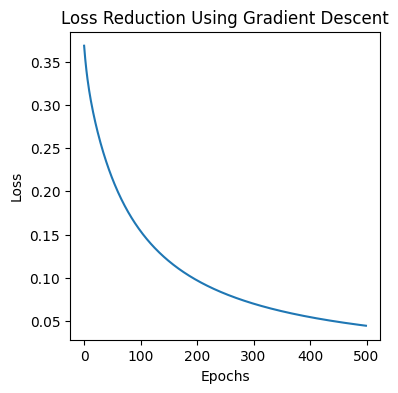

In [ ]:
#Part 2
import numpy as np
# 1. Data for OR Gate
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])
y = np.array([[0], [1], [1], [1]])

# 2. Setup
np.random.seed(0)
W = np.random.randn(2,1)
b = np.zeros((1,1))
learning_rate = 0.1
epochs = 500

def sigmoid(z):
    return 1/( 1 + np.exp(-z))

losses = []
for epoch in range(epochs):

  z = np.dot(X,W) + b
  y_hat = sigmoid(z)
  loss = -np.mean( y* np.log(y_hat) + (1-y) * np.log(1 - y_hat))
  losses.append(loss)

  dz = y_hat - y
  dW = np.dot(X.T, dz)
  db = np.sum(dz, axis = 0, keepdims=True)

  W -= learning_rate * dW
  b -= learning_rate * db

print("Final Weights")
print(W)
print("Final Bias")
print(b)

plt.figure(figsize=(4,4))
plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title('Loss Reduction Using Gradient Descent')
plt.show()

Final Predictions (Rounded):
[[0.]
 [1.]
 [1.]
 [0.]]


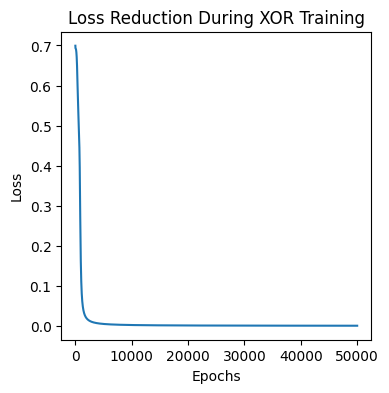

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Data for XOR Gate
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])

y = np.array([[0],
              [1],
              [1],
              [0]])

# 2. Setup
np.random.seed(1) # Changed seed from 42 to 1
input_size = 2
hidden_size = 2
output_size = 1

learning_rate = 0.5
epochs = 50000

# Initialize weights
W1 = np.random.randn(input_size, hidden_size) * 0.5
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size) * 0.5
b2 = np.zeros((1, output_size))

# Activation functions
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(a):
    return a * (1 - a)

# Training
losses = []
m = X.shape[0]

for epoch in range(epochs):
    # --- Forward Pass ---
    z1 = np.dot(X, W1) + b1
    a1 = sigmoid(z1)

    z2 = np.dot(a1, W2) + b2
    y_hat = sigmoid(z2)

    # --- Loss (Binary Cross-Entropy) ---
    loss = -np.mean(y * np.log(y_hat + 1e-8) + (1 - y) * np.log(1 - y_hat + 1e-8))
    losses.append(loss)

    # --- Backpropagation ---
    dz2 = y_hat - y
    dW2 = np.dot(a1.T, dz2) / m
    db2 = np.sum(dz2, axis=0, keepdims=True) / m

    dz1 = np.dot(dz2, W2.T) * sigmoid_derivative(a1)
    dW1 = np.dot(X.T, dz1) / m
    db1 = np.sum(dz1, axis=0, keepdims=True) / m

    # --- Update ---
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

# --- Final Predictions ---
    z1 = np.dot(X, W1) + b1
    a1 = sigmoid(z1)
    z2 = np.dot(a1, W2) + b2
    y_hat = sigmoid(z2)

print("Final Predictions (Rounded):")
print(np.round(y_hat))

# --- Plot Loss ---
plt.figure(figsize=(4,4))
plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Reduction During XOR Training")
plt.show()